In [ ]:
# notebook used in Colab for training
from google.colab import drive
drive.mount('/content/drive')
# %cd /content/drive/MyDrive/oxford-iiit-pet-noses

ModuleNotFoundError: No module named 'google.colab'

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torch.optim as optim
import numpy as np
from tqdm import tqdm
import numpy as np
import os

In [18]:
class SnoutNet(nn.Module):
    def __init__(self):
        super(SnoutNet, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, stride=2)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2, padding=1)

        self.conv2 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=2)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2, padding=1)

        self.conv3 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=2)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2, padding=1)

        self.fc1 = nn.Linear(4 * 4 * 256, 1024)
        self.fc2 = nn.Linear(1024, 1024)
        self.fc3 = nn.Linear(1024, 2)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)

        x = F.relu(self.conv2(x))
        x = self.pool2(x)

        x = F.relu(self.conv3(x))
        x = self.pool3(x)

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x

model = SnoutNet()
dummy_input = torch.randn(1, 3, 227, 227)
output = model(dummy_input)
print("Output shape:", output.shape)
print("Output tensor:", output)

Output shape: torch.Size([1, 2])
Output tensor: tensor([[-0.0050, -0.0133]], grad_fn=<AddmmBackward0>)


In [19]:
# Dataset
class PetNoseDataset(Dataset):
    def __init__(self, images_dir, annotations_file, transform=None, target_size=(227, 227)):
        self.images_dir = images_dir
        self.transform = transform
        self.target_size = target_size
        self.annotations = []
        with open(annotations_file, 'r') as f:
            for line in f.readlines():
                image_name, coord_str = line.strip().split(',', 1)
                coord = tuple(map(int, coord_str.strip('"()').split(',')))
                self.annotations.append((image_name, coord))

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        image_name, coord = self.annotations[idx]
        img_path = os.path.join(self.images_dir, image_name)
        image = Image.open(img_path).convert('RGB')
        orig_width, orig_height = image.size
        if self.transform:
            image = self.transform(image)
        x, y = coord
        x_scaled = x * (self.target_size[0] / orig_width)
        y_scaled = y * (self.target_size[1] / orig_height)
        label = torch.tensor([x_scaled, y_scaled], dtype=torch.float32)
        return image, label

Batch images shape: torch.Size([16, 3, 227, 227])
Batch labels: tensor([[ 85.5033,  91.8089],
        [152.5440, 197.0060],
        [ 63.1060,  88.2227],
        [168.6933, 104.4200],
        [ 97.1560, 107.1440],
        [ 98.5180, 137.0180],
        [107.2713, 142.5560],
        [ 76.0966, 101.0470],
        [124.8500, 105.5550],
        [134.8380, 111.7958],
        [194.3120, 100.4921],
        [ 97.0425,  94.9737],
        [117.8654, 153.4520],
        [159.5914, 101.6960],
        [ 98.5180,  85.2102],
        [111.2300,  95.8191]])


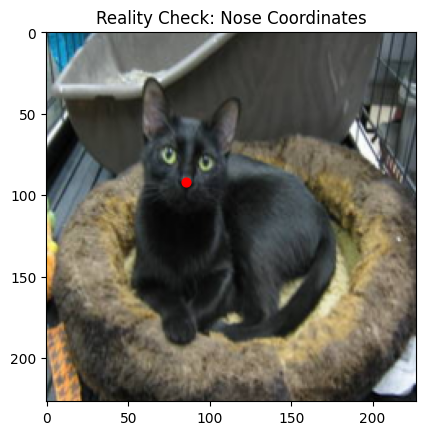

In [20]:
# Transforms
transform_no_aug = transforms.Compose([
    transforms.Resize((227,227)),
    transforms.ToTensor()
])

transform_aug = transforms.Compose([
    transforms.Resize((227,227)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomRotation(15),
    transforms.ToTensor()
])

# Copy dataset from Drive
# !cp -r /content/drive/MyDrive/oxford-iiit-pet-noses /content/
images_dir = "images-original/images"
train_file = "train_noses.txt"
test_file = "test_noses.txt"

# Train/test dataset aug vs no aug
train_dataset_no_aug = PetNoseDataset(images_dir, train_file, transform=transform_no_aug, target_size=(227,227))
test_dataset_no_aug  = PetNoseDataset(images_dir, test_file, transform=transform_no_aug, target_size=(227,227))

train_dataset_flex_aug = PetNoseDataset(images_dir, train_file, transform=transform_aug, target_size=(227,227))
test_dataset_flex_aug  = PetNoseDataset(images_dir, test_file, transform=transform_no_aug, target_size=(227,227))

# DataLoaders
batch_size = 16

train_loader_no_aug = DataLoader(train_dataset_no_aug, batch_size=batch_size, shuffle=True)
test_loader_no_aug  = DataLoader(test_dataset_no_aug, batch_size=batch_size, shuffle=False)
train_loader_aug = DataLoader(train_dataset_flex_aug, batch_size=batch_size, shuffle=True)
test_loader_aug  = DataLoader(test_dataset_flex_aug, batch_size=batch_size, shuffle=False)

# plot image coords to test
for images, labels in train_loader_no_aug:
    print("Batch images shape:", images.shape)
    print("Batch labels:", labels)

    img = images[0].permute(1, 2, 0).numpy()
    x, y = labels[0]

    plt.imshow(img)
    plt.scatter(x, y, c='r', s=40)
    plt.title("Reality Check: Nose Coordinates")
    plt.show()
    break


In [21]:
# Pretrained models
class AlexNetNose(nn.Module):
    def __init__(self, pretrained=True):
        super(AlexNetNose, self).__init__()
        self.alex = models.alexnet(pretrained=pretrained)
        self.alex.classifier = nn.Sequential(
            nn.Dropout(),
            nn.Linear(256 * 6 * 6, 1024),
            nn.ReLU(),
            nn.Dropout(),
            nn.Linear(1024, 1024),
            nn.ReLU(),
            nn.Linear(1024, 2)
        )
    def forward(self, x):
        return self.alex(x)

class VGG16Nose(nn.Module):
    def __init__(self, pretrained=True):
        super(VGG16Nose, self).__init__()
        self.vgg = models.vgg16(pretrained=pretrained)
        self.vgg.classifier = nn.Sequential(
            nn.Linear(512*7*7, 4096),
            nn.ReLU(),
            nn.Dropout(),
            nn.Linear(4096, 1024),
            nn.ReLU(),
            nn.Linear(1024, 2)
        )
    def forward(self, x):
        return self.vgg(x)

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
print(torch.cuda.get_device_name(0))

cuda
NVIDIA A100-SXM4-80GB


In [23]:
def train_model(model, train_loader, test_loader, device, num_epochs=10, lr=1e-3):
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_losses, val_losses = [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0
        for images, labels in tqdm(train_loader):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
        train_loss = running_loss / len(train_loader.dataset)
        train_losses.append(train_loss)

        model.eval()
        val_loss_total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                val_loss_total += criterion(outputs, labels).item() * images.size(0)
        val_loss = val_loss_total / len(test_loader.dataset)
        val_losses.append(val_loss)

        print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    return model, train_losses, val_losses

In [24]:
# SnoutNet
snout_no_aug, _, _ = train_model(SnoutNet(), train_loader_no_aug, test_loader_no_aug, device)
torch.save(snout_no_aug.state_dict(), "snoutnet_no_aug.pth")
torch.cuda.empty_cache()

snout_aug, _, _ = train_model(SnoutNet(), train_loader_aug, test_loader_no_aug, device)
torch.save(snout_aug.state_dict(), "snoutnet_aug.pth")
torch.cuda.empty_cache()

100%|██████████| 344/344 [00:42<00:00,  8.19it/s]


Epoch [1/10] Train Loss: 1469.6383 | Val Loss: 1168.8865


100%|██████████| 344/344 [00:42<00:00,  8.18it/s]


Epoch [2/10] Train Loss: 1178.0144 | Val Loss: 1414.0950


100%|██████████| 344/344 [00:42<00:00,  8.17it/s]


...

Epoch [8/10] Train Loss: 1120.1405 | Val Loss: 1195.3337


100%|██████████| 344/344 [00:52<00:00,  6.59it/s]


Epoch [9/10] Train Loss: 1106.7897 | Val Loss: 1127.1372


100%|██████████| 344/344 [00:52<00:00,  6.55it/s]


Epoch [10/10] Train Loss: 1082.9691 | Val Loss: 1167.3734


In [25]:
# AlexNet
alex_no_aug, _, _ = train_model(AlexNetNose(), train_loader_no_aug, test_loader_no_aug, device)
torch.save(alex_no_aug.state_dict(), "alexnet_no_aug.pth")
torch.cuda.empty_cache()

alex_aug, _, _ = train_model(AlexNetNose(), train_loader_aug, test_loader_no_aug, device)
torch.save(alex_aug.state_dict(), "alexnet_aug.pth")
torch.cuda.empty_cache()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 344/344 [00:43<00:00,  7.94it/s]


Epoch [1/10] Train Loss: 2184.9453 | Val Loss: 1147.1410


100%|██████████| 344/344 [00:42<00:00,  8.01it/s]


Epoch [2/10] Train Loss: 963.8760 | Val Loss: 877.9506


100%|██████████| 344/344 [00:42<00:00,  8.06it/s]


...

Epoch [8/10] Train Loss: 941.5756 | Val Loss: 771.7854


100%|██████████| 344/344 [00:53<00:00,  6.46it/s]


Epoch [9/10] Train Loss: 937.4787 | Val Loss: 839.8314


100%|██████████| 344/344 [00:53<00:00,  6.48it/s]


Epoch [10/10] Train Loss: 911.1474 | Val Loss: 862.6502


In [26]:
# VGG16
vgg_no_aug, _, _ = train_model(VGG16Nose(), train_loader_no_aug, test_loader_no_aug, device)
torch.save(vgg_no_aug.state_dict(), "vgg16_no_aug.pth")
torch.cuda.empty_cache()

vgg_aug, _, _ = train_model(VGG16Nose(), train_loader_aug, test_loader_no_aug, device)
torch.save(vgg_aug.state_dict(), "vgg16_aug.pth")
torch.cuda.empty_cache()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 227MB/s]
100%|██████████| 344/344 [00:55<00:00,  6.15it/s]


Epoch [1/10] Train Loss: 3098170.9417 | Val Loss: 1257.5086


100%|██████████| 344/344 [00:54<00:00,  6.35it/s]


...

Epoch [8/10] Train Loss: 1233.1218 | Val Loss: 1412.3383


100%|██████████| 344/344 [01:04<00:00,  5.30it/s]


Epoch [9/10] Train Loss: 1227.5135 | Val Loss: 1145.1423


100%|██████████| 344/344 [01:04<00:00,  5.32it/s]


Epoch [10/10] Train Loss: 1213.9886 | Val Loss: 1186.7243


In [27]:
def ensemble_predict(models, loader, device):
    for m in models:
        m.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            preds = sum([m(images) for m in models]) / len(models)
            all_preds.append(preds.cpu())
            all_labels.append(labels)

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    distances = torch.sqrt(torch.sum((all_preds - all_labels)**2, dim=1)).numpy()
    print("Ensemble Localization Accuracy (pixels):")
    print(f"Minimum: {distances.min():.2f} | Mean: {distances.mean():.2f} | Max: {distances.max():.2f} | Std: {distances.std():.2f}")

# Ensemble with no augmentation
ensemble_models_no_aug = [snout_no_aug.to(device), alex_no_aug.to(device), vgg_no_aug.to(device)]
ensemble_predict(ensemble_models_no_aug, test_loader_no_aug, device)

# Ensemble with augmentation (use training from aug, but test on no-aug)
ensemble_models_aug = [snout_aug.to(device), alex_aug.to(device), vgg_aug.to(device)]
ensemble_predict(ensemble_models_aug, test_loader_no_aug, device)

Ensemble Localization Accuracy (pixels):
Minimum: 0.40 | Mean: 20.72 | Max: 126.96 | Std: 16.98
Ensemble Localization Accuracy (pixels):
Minimum: 1.44 | Mean: 37.36 | Max: 126.32 | Std: 22.69
